<a href="https://colab.research.google.com/github/Karnik2001/-Gated-Recurrent-Unit-Networks-Using-Time-Series-Data/blob/main/Amazon_Product_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from textblob import TextBlob
import string
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
amazon = pd.read_csv('/content/amazon_reviews.csv')
amazon.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,207ad181-f03d-49c3-a87c-e9dd3745d3ec,Khaled Hammad,الشركة تقوم بعروض وهمية وبعد الشراء تضيع الشحنة,1,0,30.21.0.100,2025-12-04 10:32:34,30.21.0.100
1,63f983a5-37a5-45f7-a576-cb6adfab2ceb,reinhardt de Necker,they have excellent service customer service a...,5,0,30.21.0.100,2025-12-04 10:21:37,30.21.0.100
2,214a58d7-b1d9-46ed-b196-3fc7411e7eb4,Amantle monne,it delivered my product very fast and exactly ...,5,0,30.21.0.100,2025-12-04 09:52:42,30.21.0.100
3,29c8cad1-f93e-49a0-8f53-10652c5a9728,MARTIN ESPITIA-SANCHEZ,P fast,5,0,30.21.0.100,2025-12-04 09:44:48,30.21.0.100
4,8ef9ddf7-8718-4ea3-ac34-fa31f8e7ef8f,RAMAH,cash on delivery is very expensive but the pro...,4,0,30.21.0.100,2025-12-04 09:37:43,30.21.0.100


In [3]:
amazon = amazon.drop(columns=['reviewId','userName','reviewCreatedVersion','at','appVersion'])
amazon.head()

,content,score,thumbsUpCount
0,الشركة تقوم بعروض وهمية وبعد الشراء تضيع الشحنة,1,0
1,they have excellent service customer service a...,5,0
2,it delivered my product very fast and exactly ...,5,0
3,P fast,5,0
4,cash on delivery is very expensive but the pro...,4,0


In [4]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = "".join([word.lower() for word in text if word not in string.punctuation])
    text = text.lower()
    return text

In [5]:
amazon['cleaned_text'] = amazon['content'].astype(str).apply(clean_text)
amazon.head()

,content,score,thumbsUpCount,cleaned_text
0,الشركة تقوم بعروض وهمية وبعد الشراء تضيع الشحنة,1,0,
1,they have excellent service customer service a...,5,0,they have excellent service customer service a...
2,it delivered my product very fast and exactly ...,5,0,it delivered my product very fast and exactly ...
3,P fast,5,0,p fast
4,cash on delivery is very expensive but the pro...,4,0,cash on delivery is very expensive but the pro...


In [6]:
amazon.isnull().sum()

,0
content,6
score,0
thumbsUpCount,0
cleaned_text,0


In [7]:
amazon = amazon.dropna()
amazon.isnull().sum()

,0
content,0
score,0
thumbsUpCount,0
cleaned_text,0


In [8]:
amazon_tfidf = TfidfVectorizer(max_features=1000)

In [9]:
X = amazon_tfidf.fit_transform(amazon['cleaned_text'])

In [10]:
amazon['sentiment'] = amazon['content'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

In [11]:
def get_sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'
amazon['sentiment_label'] = amazon['sentiment'].apply(get_sentiment_label)

In [12]:
y = amazon['sentiment_label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [14]:
amazon_log = LogisticRegression()
amazon_log.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_pred  = amazon_log.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      5133
     neutral       0.85      0.88      0.87      2539
    positive       0.91      0.91      0.91      8632

    accuracy                           0.88     16304
   macro avg       0.87      0.88      0.87     16304
weighted avg       0.88      0.88      0.88     16304



In [17]:
def predict_sentiment(review):
    review_cleaned = clean_text(review)
    review_tfidf = amazon_tfidf.transform([review_cleaned])
    sentiment_label = amazon_log.predict(review_tfidf)[0]
    return sentiment_label

new_review = "This product is amazing and works perfectly!"
print(f'Review: {new_review}')
print(f'Sentiment: {predict_sentiment(new_review)}')


Review: This product is amazing and works perfectly!
Sentiment: positive


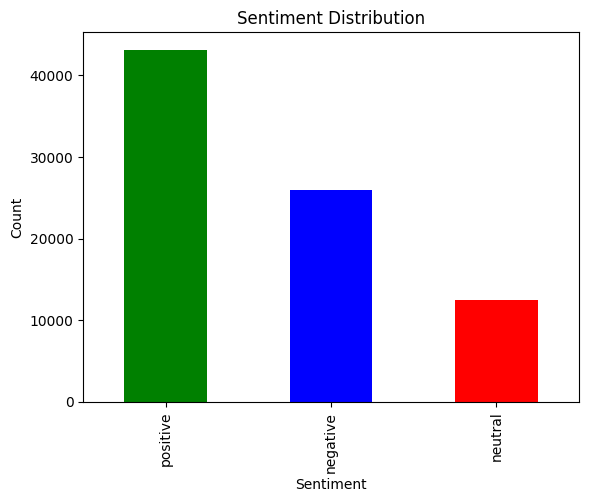

In [18]:
amazon['sentiment_label'].value_counts().plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()

In [19]:
iface = gr.Interface(fn=predict_sentiment,
                     inputs=gr.Textbox(lines=5, label="Enter your review here"),
                     outputs="text",
                     title="Amazon Review Sentiment Predictor",
                     description="Enter a product review to get its sentiment (positive, neutral, or negative).")

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2e73e07bcaa28df19.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
